### 지도학습 절차

- 지도학습 : 목표변수(Y)와 설명변수(X)의 관계를 학습해서, 새로운 X가 들어올 때, Y를 예측 / 분류

- 지도학습의 절차 6단계:
  1. 데이터 핸들링 (데이터 불러오기 / 파생변수 생성 / 층별화) : 데이터 구조적인 관점에서 학습을 수행할 수 있는 데이터셋을 구성하는 과정

  2. 학습에 사용될 목표변수(Y)와 설명변수(X)를 설정
    - 유의사항 : 사용되는 X는 새로 들어올 데이터에 대한 값으로 지정 ex. 신규고객 이탈 예측을 할 때 구매횟수와 방문횟수를 넣으면 안 됨.

  3. 학습 데이터(Train Set)와 검증 데이터(Test Set)분할
    - 검증 데이터(Test Set)는 학습에 참여하지 않는다! (교차검증에서 Validation Set과는 다른 개념)

  4. 학습을 수행 (Modeling)
    - 특성공학 (결측값 처리 / Encoding / Scaling ...) -> Pipe Line을 이용해서
    - 학습 (알고리즘)

  5. 학습된 모델 평가
    - 학습 능력 평가
    - 일반화 능력 평가


In [405]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

- 사용한 데이터 (https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

In [406]:
# 데이터 불러오기
df1 = pd.read_csv('/Users/daehyun/Documents/BAF/과제3/2주차/diabetes.csv')
print(df1.shape)
print(df1.info())
print(df1.head())
print(df1.tail())

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2         

In [407]:
# 환자의 건강 관련 정보를 입력했을 때, 당뇨병에 걸릴지 말지에 대한 판별 모델 생성
# 1) 데이터 핸들링
df1['Outcome'].unique()

array([1, 0])

## **결측치는 없지만 0이 나올 수 있는 변수와 아닌 변수를 구분해서 EDA 할 것**

### 당뇨병이란?? <br>

-> 혈액 속 포도당 수치가 높은 상태가 지속되는 만성질환

-> Glucose, BloodPressure, SkinThickness, Insulin, BMI는 0이 될 수 없음. 이상치 존재 여부 또한 확인해볼 필요가 있음. <br>
=> barplot, boxplot 등 확인해볼 필요가 있음. <br>

**• 임신 경험이 많을 수록 임신성 당뇨 경험에 의해 당뇨 위험성이 높을 수 있다.** <br><br>
**• 글루코젠이 높을 수록 혈당 조절 이상 가능성이 높아 당뇨 위험성이 높다.** <br><br>
**• 혈압이 높을 수록 비만 위험성이 있고, BMI가 높을 수록 당뇨 위험성이 있다.** <br><br>
**• 인슐린이 높을수록 과다 분비 위험성이 있어, 인슐린 저항성이 낮아져 당뇨병 걸림 확률이 높아질 수 있다.**


## **Pregrance**
 - 임신횟수

In [408]:
# 셀 추가해서 EDA 하기
df1['Pregnancies'].describe()

count    768.000000
mean       3.845052
std        3.369578
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: Pregnancies, dtype: float64

In [409]:
df1['Pregnancies'].value_counts()

Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
15      1
17      1
Name: count, dtype: int64

Text(0, 0.5, 'the number of people')

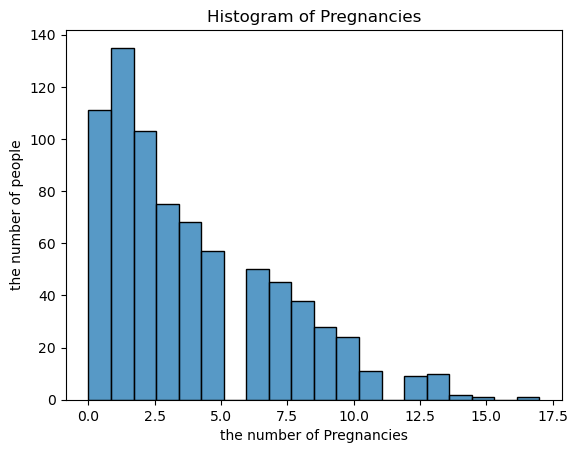

In [410]:
# 임신 횟수에 따른 실험군 개수 확인.
sns.histplot(df1['Pregnancies'], bins = 20)
plt.title('Histogram of Pregnancies')
plt.xlabel('the number of Pregnancies')
plt.ylabel('the number of people')

In [411]:
# outcome에 따른 Pregnancies 통계량 확인
df1.groupby('Outcome')['Pregnancies'].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,500.0,3.298000,3.017185,0.0,1.00,2.0,5.0,13.0
1,268.0,4.865672,3.741239,0.0,1.75,4.0,8.0,17.0


/var/folders/3t/75nxhs_x6gz3sd68vbz2t1qh0000gn/T/ipykernel_5882/4173445984.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Outcome', y = 'Pregnancies', data = df1,


Text(0, 0.5, 'Pregnancies')

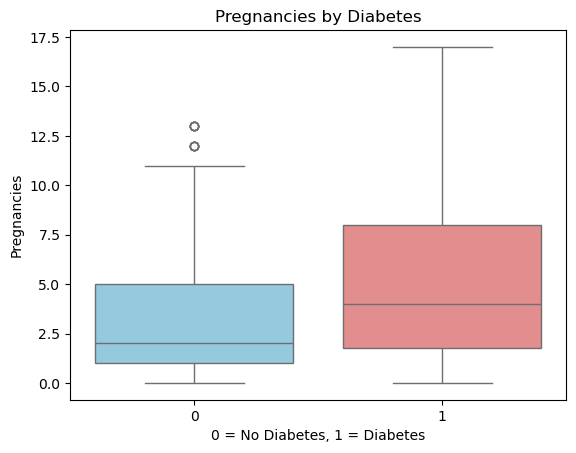

In [412]:
# outcome에 따른 pregnancies boxplot
sns.boxplot(x = 'Outcome', y = 'Pregnancies', data = df1,
            palette = ['skyblue', 'lightcoral'])
plt.title('Pregnancies by Diabetes')
plt.xlabel('0 = No Diabetes, 1 = Diabetes')
plt.ylabel('Pregnancies')

### **변수 인사이트 정리**

• 당뇨에 걸린 환자가 아닌 환자보다 임신 횟수에 중앙값, 평균값이 높게 측정되었다.<br><br>
• boxplot에서 볼 수 있듯, 당뇨병가 있는 환자들은 임신 횟수가 상대적으로 더 많다. <br><br>
• 임신 횟수가 많을 수록 당뇨에 걸릴 확률이 높을 수 있다는 지표가 될 수 있다.

## **glucose**
- 혈장 포도당 농도
- 사람 혈당이 0일 수는 없다.
- 당뇨는 혈당이 지속적으로 높은 증상

In [413]:
df1['Glucose'].describe()

count    768.000000
mean     120.894531
std       31.972618
min        0.000000
25%       99.000000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64

In [414]:
# 셀 추가해서 EDA 하기
(df1['Glucose'] == 0).sum()

np.int64(5)

Text(0, 0.5, 'the number of people')

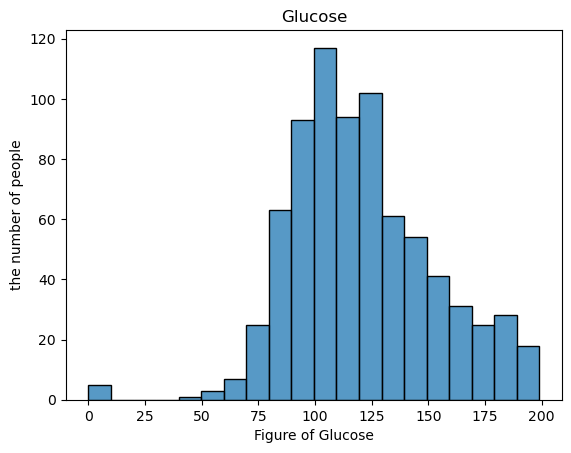

In [415]:
# Glucose 분포도 확인
sns.histplot(df1['Glucose'], bins = 20)
plt.title('Glucose')
plt.xlabel('Figure of Glucose')
plt.ylabel('the number of people')

In [416]:
# 어떤 값으로 결측치를 대체할지 확인.
# 평균값이 가장 이로울 듯 함.
df1['Glucose'].describe()

count    768.000000
mean     120.894531
std       31.972618
min        0.000000
25%       99.000000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64

In [417]:
df1['Glucose'] = df1['Glucose'].replace(0, np.nan)
df1['Glucose'].isna().sum()

np.int64(5)

In [418]:
df1['Glucose'] = df1['Glucose'].transform(lambda x: x.fillna(x.mean()))

Text(0, 0.5, 'Count')

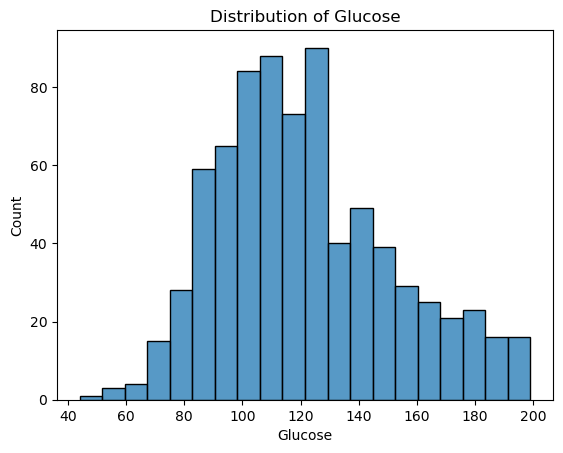

In [419]:
# Glucose histogram 확인해보기 / 전과 확실히 바뀜. 결측치 제거 완료. 
sns.histplot(df1['Glucose'], bins = 20)
plt.title('Distribution of Glucose')
plt.xlabel('Glucose')
plt.ylabel('Count')

In [420]:
# Outcome에 따른 Glucose 확인
df1.groupby('Outcome')['Glucose'].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,500.0,110.710121,24.71706,44.0,93.0,107.5,125.0,197.0
1,268.0,142.165573,29.54175,78.0,119.0,140.0,167.0,199.0


/var/folders/3t/75nxhs_x6gz3sd68vbz2t1qh0000gn/T/ipykernel_5882/292903711.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Outcome', y = 'Glucose', data = df1,


Text(0, 0.5, 'Glucose')

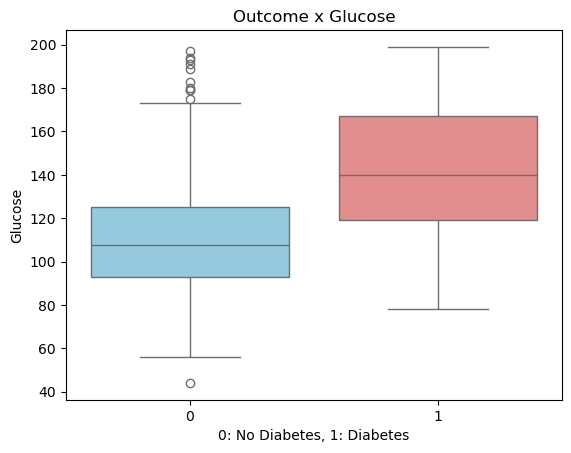

In [421]:
sns.boxplot(x = 'Outcome', y = 'Glucose', data = df1,
            palette = ['skyblue', 'lightcoral'])
plt.title('Outcome x Glucose')
plt.xlabel('0: No Diabetes, 1: Diabetes')
plt.ylabel('Glucose')

### **변수 인사이트 정리**

• Glucose 결측치를 평균값으로 대체. <br>
-> 대체 사유: 중앙값, 평균값 두 값들 중 크게 차이날 것이 없다 생각하였음 / 더욱 가운데 값인 평균값으로 대체.<br><br>
• 당뇨병이 있는 환자들은 글루코젠 수치가 상대적으로 더 크게 측정됨. <br><br>
• 글루코젠 수치는 당뇨병 가능성에 핵심지표

## **bloodpressure**
- 혈압
- 혈압도 0일 수는 없다 

In [422]:
# 셀 추가해서 EDA 하기
df1['BloodPressure'].describe()

count    768.000000
mean      69.105469
std       19.355807
min        0.000000
25%       62.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64

Text(0, 0.5, 'Count')

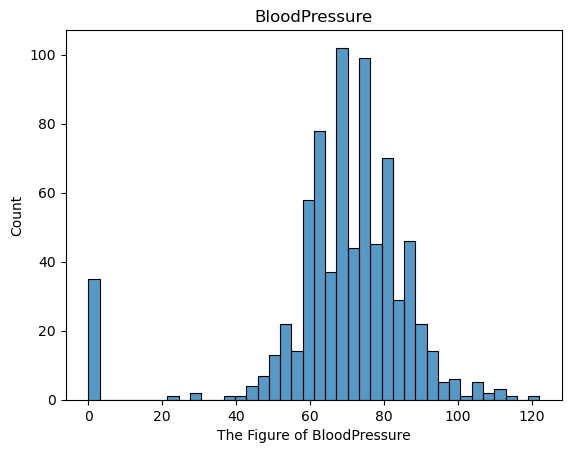

In [423]:
sns.histplot(df1['BloodPressure'], bins = 40)
plt.title('BloodPressure')
plt.xlabel('The Figure of BloodPressure')
plt.ylabel('Count')

In [424]:
(df1['BloodPressure'] == 0).sum()

np.int64(35)

In [425]:
df1['BloodPressure'] = df1['BloodPressure'].replace(0, np.nan)
df1['BloodPressure'].isna().sum()

np.int64(35)

In [426]:
df1['BloodPressure'] = df1['BloodPressure'].transform(lambda x: x.fillna(x.median()))
df1['BloodPressure'].isna().sum()

np.int64(0)

Text(0, 0.5, 'Count')

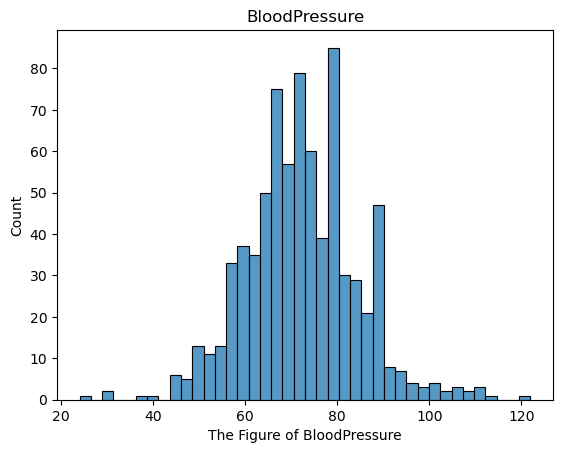

In [427]:
sns.histplot(df1['BloodPressure'], bins = 40)
plt.title('BloodPressure')
plt.xlabel('The Figure of BloodPressure')
plt.ylabel('Count')

In [428]:
df1.groupby('Outcome')['BloodPressure'].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,500.0,70.920000,11.929385,24.0,63.5,72.0,78.0,122.0
1,268.0,75.123134,11.951672,30.0,68.0,74.0,82.0,114.0


/var/folders/3t/75nxhs_x6gz3sd68vbz2t1qh0000gn/T/ipykernel_5882/2912987629.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Outcome', y = 'BloodPressure', data = df1,


Text(0, 0.5, 'BloodPressure')

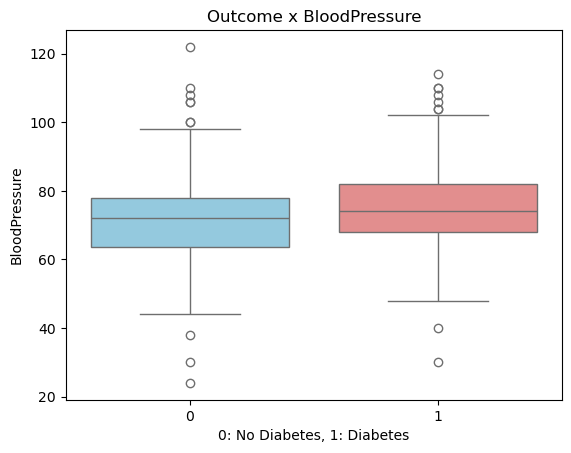

In [429]:
sns.boxplot(x = 'Outcome', y = 'BloodPressure', data = df1,
            palette = ['skyblue', 'lightcoral'])
plt.title('Outcome x BloodPressure')
plt.xlabel('0: No Diabetes, 1: Diabetes')
plt.ylabel('BloodPressure')

### **변수 인사이트 정리**

• BloodPressure 결측치를 중앙값으로 대체.<br><br>
-> 대체 사유: 이상치는 없었으나, 깂들이 평균값보다 중앙값에 더욱 밀집해있었음. <br><br>
• boxplot을 보았을 떄, 당뇨병 환자의 혈압 수치가 근소하게 높은 것으로 측정됨. <br><br>
-> 혈압이 높을 수록 당뇨 위험성이 있으나, 핵심 지표로 사용하기에는 부적합하다고 판단할 수 있음.

## **SkinThickness**
- 삼두근 피부 두께
- 체지방이란 관련이 있다.
- 0일 수 없다

In [430]:
# 셀 추가해서 EDA 하기
df1['SkinThickness'].describe()

count    768.000000
mean      20.536458
std       15.952218
min        0.000000
25%        0.000000
50%       23.000000
75%       32.000000
max       99.000000
Name: SkinThickness, dtype: float64

In [431]:
# 결측치 확인
(df1['SkinThickness'] == 0).sum()

np.int64(227)

Text(0, 0.5, 'Count')

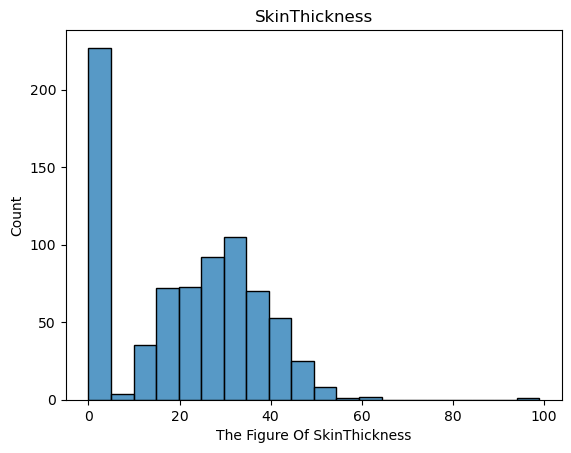

In [432]:
sns.histplot(df1['SkinThickness'], bins = 20)
plt.title('SkinThickness')
plt.xlabel('The Figure Of SkinThickness')
plt.ylabel('Count')

• 그래프에서 볼 수 있듯, max값이 99로 이상치가 존재. 평균값이 상이해질 수 있음. <br>
• 결측치를 대신할 값은 중앙값이 타당함.

In [433]:
df1['SkinThickness'] = df1['SkinThickness'].replace(0, np.nan)
df1['SkinThickness'].isna().sum()

np.int64(227)

In [434]:
df1['SkinThickness'] = df1['SkinThickness'].transform(lambda x: x.fillna(x.median()))

### **변수 인사이트 정리**

Text(0, 0.5, 'Count')

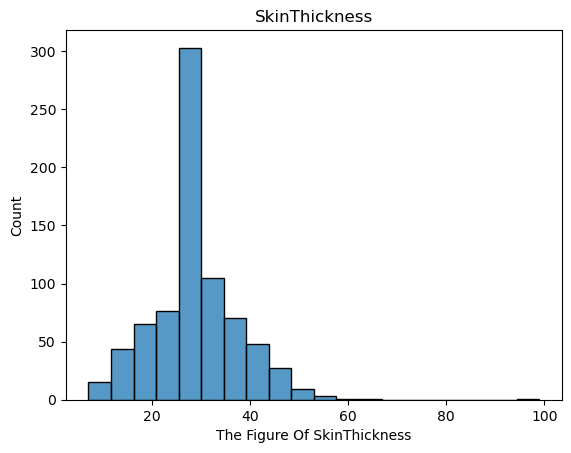

In [435]:
# 결측치 사라졌는지, 재확인
sns.histplot(df1['SkinThickness'], bins = 20)
plt.title('SkinThickness')
plt.xlabel('The Figure Of SkinThickness')
plt.ylabel('Count')

In [436]:
df1.groupby('Outcome')['SkinThickness'].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,500.0,27.726000,8.552966,7.0,22.0,29.0,31.0,60.0
1,268.0,31.686567,8.662994,7.0,29.0,29.0,36.0,99.0


/var/folders/3t/75nxhs_x6gz3sd68vbz2t1qh0000gn/T/ipykernel_5882/2290527434.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Outcome', y = 'SkinThickness', data = df1,


Text(0, 0.5, 'SkinThickness')

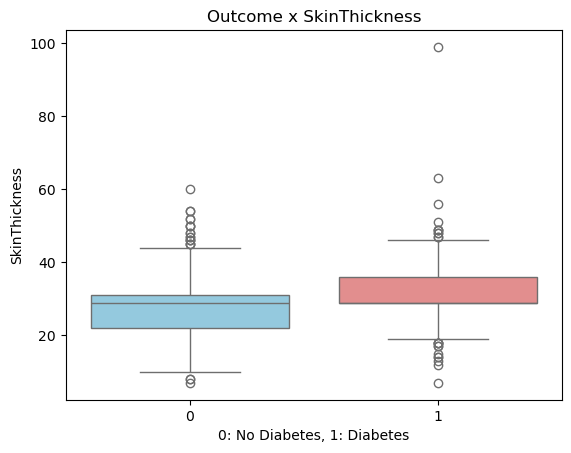

In [437]:
sns.boxplot(x = 'Outcome', y = 'SkinThickness', data = df1,
            palette = ['skyblue', 'lightcoral'])
plt.title('Outcome x SkinThickness')
plt.xlabel('0: No Diabetes, 1: Diabetes')
plt.ylabel('SkinThickness')

• SkinThickness 결측치는 중앙값으로 대체함. <br><br>
• boxplot을 확인해보았을 때, 당뇨병이 있는 사람들이 SkinThickness가 높은 것으로 확인됨.<br><br>
-> 그러나 당뇨병이 아닌 환자들과 비교했을 때, 극명하게 차이가 나지 않기 떄문에 핵심지표라 하기에는 어려움.

## **Insulin**
- 인슐린 분비량
- 당뇨병 유형은 인슐린이 선천적으로 나오지 않는 사람(1형)과 인슐린이 나오지만 인식을 못하는 사람(2형) 당뇨병 두가지가 있다.  

In [438]:
# 셀 추가해서 EDA 하기
df1['Insulin'].describe()

count    768.000000
mean      79.799479
std      115.244002
min        0.000000
25%        0.000000
50%       30.500000
75%      127.250000
max      846.000000
Name: Insulin, dtype: float64

Text(0, 0.5, 'Count')

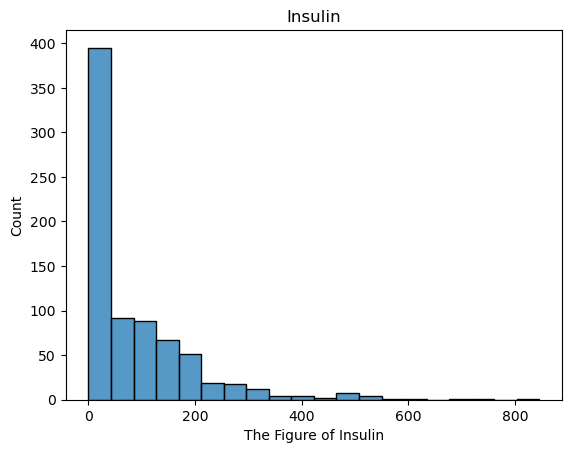

In [439]:
sns.histplot(df1['Insulin'], bins = 20)
plt.title('Insulin')
plt.xlabel('The Figure of Insulin')
plt.ylabel('Count')

In [440]:
(df1['Insulin'] == 0).sum()

np.int64(374)

• 인슐린 1형; 주로 소아•청소년에게 발병됨. <br><br>
-> 본 데이터는 성인 여성들이 주를 이루는 데이터임. 인슐린이 1형인 인원의 수는 적을 것이라 판단. <br><br>
-> 즉 값이 '0'인 것은 결측치로 판단하여 다른 값으로 대체하여도 상관없다고 생각함. <br><br>
• 인슐린은 글루코젠과 연관성이 있음. 혈당이 높을수록 인슐린 과다분비 확률이 높음. <br><br>
-> 인슐린과 글루코젠 관계성 확인.

In [441]:
# Insulin / Glucose 독립성 검정
from scipy.stats import chi2_contingency   # 독립성 검정할 때 가져와야할 라이브러리!

q1 = df1['Glucose'].quantile(0.25)
q3 = df1['Glucose'].quantile(0.75)

df1['Glucose_group'] = pd.cut(
    df1['Glucose'],
    bins=[-float('inf'), q1, q3, float('inf')],
    labels=['low', 'middle', 'high']
)

ct_Glucose = pd.crosstab(df1['Insulin'], df1['Glucose'])

chi2, p, dof, expected = chi2_contingency(ct_Glucose)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 27248.6101
p-value: 0.0000
Degrees of freedom: 24975


In [442]:
# 인슐린 400 이상은 희박한 확률임. 0으로 대체하겠습니다
df1.loc[df1['Insulin'] > 400, 'Insulin'] = 0

In [443]:
# Insulin과 Glucose 유의미한 의미가 있다.
df1['Insulin'] = df1['Insulin'].replace(0, np.nan)
df1['Insulin'].isna().sum()

np.int64(394)

In [444]:
df1.groupby('Glucose_group')['Insulin'].describe()

/var/folders/3t/75nxhs_x6gz3sd68vbz2t1qh0000gn/T/ipykernel_5882/4028313032.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby('Glucose_group')['Insulin'].describe()


,count,mean,std,min,25%,50%,75%,max
Glucose_group,,,,,,,,
low,102.0,74.303922,40.471916,15.0,49.0,66.0,88.0,258.0
middle,183.0,140.551913,65.077437,22.0,94.0,130.0,180.0,370.0
high,89.0,194.269663,85.975256,14.0,130.0,180.0,265.0,392.0


In [445]:
# 결측치를 Glucose_group 구간별 Insulin 중앙값으로 대체함.
df1['Insulin'] = df1.groupby('Glucose_group')['Insulin'].transform(lambda x: x.fillna(x.median()))
df1['Insulin'].isna().sum()

/var/folders/3t/75nxhs_x6gz3sd68vbz2t1qh0000gn/T/ipykernel_5882/3166491173.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1['Insulin'] = df1.groupby('Glucose_group')['Insulin'].transform(lambda x: x.fillna(x.median()))


np.int64(0)

Text(0, 0.5, 'Count')

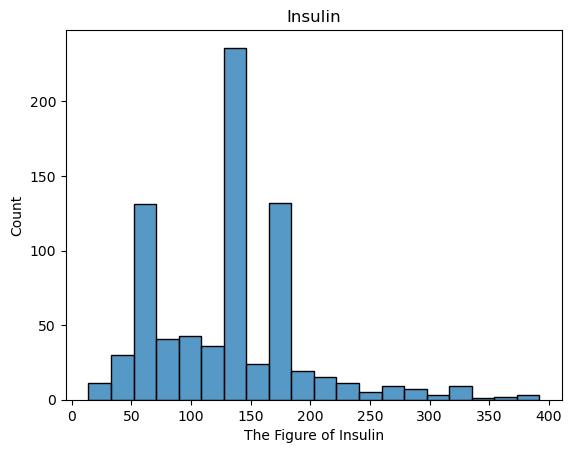

In [446]:
sns.histplot(df1['Insulin'], bins = 20)
plt.title('Insulin')
plt.xlabel('The Figure of Insulin')
plt.ylabel('Count')

In [447]:
df1.groupby('Outcome')['Insulin'].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,500.0,116.098000,58.933137,15.0,66.0,125.0,130.0,387.0
1,268.0,161.011194,55.747860,14.0,130.0,159.5,180.0,392.0


/var/folders/3t/75nxhs_x6gz3sd68vbz2t1qh0000gn/T/ipykernel_5882/3471036612.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Outcome', y = 'Insulin', data = df1,


Text(0, 0.5, 'Insulln')

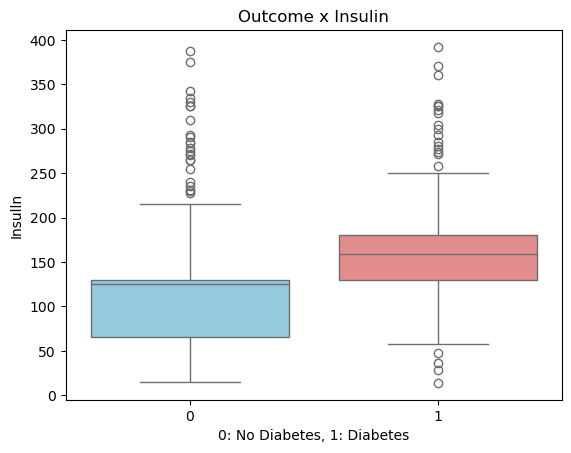

In [448]:
sns.boxplot(x = 'Outcome', y = 'Insulin', data = df1,
            palette = ['skyblue', 'lightcoral'])
plt.title('Outcome x Insulin')
plt.xlabel('0: No Diabetes, 1: Diabetes')
plt.ylabel('Insulln')

### **변수 인사이트 정리**


• 당뇨병 1형은 소아•청소년이 '주'이기 때문에, 0을 단순 결측치로 판단하였음. 추가로 인슐린 400 초과는 결측치로 판단.<br><br>
• 추가로, 인슐린은 혈당이 높을 수록 과다분비 될 수 있음. 따라서 관계성이 있다 판단함. <br><br>
-> 결측치들을 글루코젠 퍼센타일을 정해서 구간을 나눈 후, 구간 별로 중앙값을 설정하였음.<br><br><br><br>
• 당뇨병 환자일수록 인슐린 수치가 크게 나타남. 즉 인슐린이 높을 수록 당뇨에 걸릴 확률이 크다.<br><br>
-> 그러나 특정 이상치도 분명 존재하기에, 예외가 있다는 점을 명심해야함.


## **BMI**
- 0이 나올 수 없는 값

In [449]:
# 셀 추가해서  EDA 하기
df1['BMI'].describe()

count    768.000000
mean      31.992578
std        7.884160
min        0.000000
25%       27.300000
50%       32.000000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64

Text(0.5, 1.0, 'BMI')

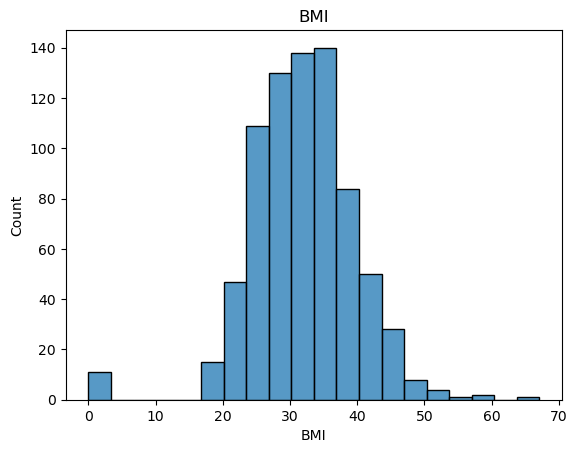

In [450]:
sns.histplot(df1['BMI'], bins = 20)
plt.title('BMI')

In [451]:
# 결측치 제거 
df1['BMI'] = df1['BMI'].replace(0, np.nan)
df1['BMI'].isna().sum()

np.int64(11)

In [452]:
# BMI는 SkinThickness와 연관성이 있을 수 있다 생각하였음.
q1 = df1['SkinThickness'].quantile(0.25)
q3 = df1['SkinThickness'].quantile(0.75)

# ST_group = SkinThickness_group
df1['ST_group'] = pd.cut(
    df1['SkinThickness'],
    bins = [-float('inf'), q1, q3, float('inf')],
    labels = ['Low', 'Middle', 'High'],
    right = False
)

df1.groupby('ST_group')['BMI'].describe()

/var/folders/3t/75nxhs_x6gz3sd68vbz2t1qh0000gn/T/ipykernel_5882/3090394253.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby('ST_group')['BMI'].describe()


,count,mean,std,min,25%,50%,75%,max
ST_group,,,,,,,,
Low,182.0,27.571429,4.632370,18.2,24.4,27.45,30.325,45.4
Middle,356.0,31.922472,6.180615,18.2,27.6,32.00,35.425,52.9
High,219.0,37.387671,6.439278,21.8,33.6,37.10,40.650,67.1


In [453]:
ct_ST = pd.crosstab(df1['BMI'], df1['ST_group'])

chi2, p, dof, expected = chi2_contingency(ct_ST)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 627.3158
p-value: 0.0000
Degrees of freedom: 492


• p-value < 0.05 이므로 BMI와 SkinThickness는 유의미한 관계가 있음.

In [454]:
# 결측치를 구간을 나눈 SkinThickness에 따른 중앙값으로 대체.
df1['BMI'] = df1.groupby('ST_group')['BMI'].transform(lambda x: x.fillna(x.median()))

/var/folders/3t/75nxhs_x6gz3sd68vbz2t1qh0000gn/T/ipykernel_5882/1110556829.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1['BMI'] = df1.groupby('ST_group')['BMI'].transform(lambda x: x.fillna(x.median()))


In [455]:
df1.groupby('Outcome')['BMI'].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,500.0,30.862000,6.506287,18.2,25.75,30.30,35.300,57.3
1,268.0,35.381343,6.596704,22.9,30.90,34.25,38.775,67.1


/var/folders/3t/75nxhs_x6gz3sd68vbz2t1qh0000gn/T/ipykernel_5882/1287707793.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Outcome', y = 'BMI', data = df1,


Text(0, 0.5, 'BMI')

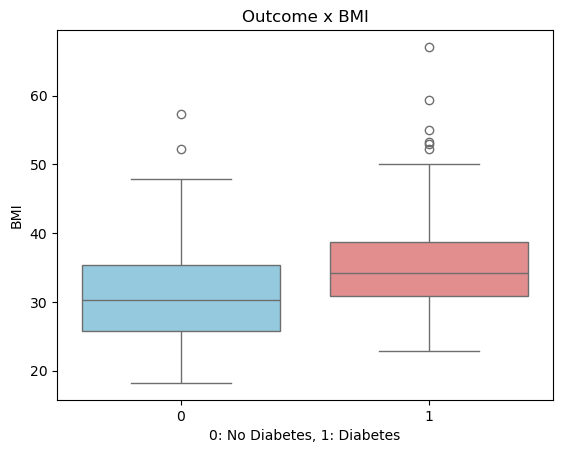

In [456]:
sns.boxplot(x = 'Outcome', y = 'BMI', data = df1,
            palette = ['skyblue', 'lightcoral'])
plt.title('Outcome x BMI')
plt.xlabel('0: No Diabetes, 1: Diabetes')
plt.ylabel('BMI')

### 변수 인사이트 정리

• BMI는 SkinThickness(피부 두께)과 관련이 있다 생각하여 범주를 나누었고, 이에 따른 범주 내에서 BMI값의 중앙값으로 결측치를 대체함.<br><br>
• 이상치는 최소화하였고, 당뇨병 걸린 환자들의 평균 BMI가 아닌 사람들보다 약소하게 높게 측정됨.<br><br>
-> BMI가 높을 수록 당뇨가 있을 확률이 약소하게 클 수 있음. 다만 핵심지표라고 하기엔 어려움이 있다.

## **파생변수 생성 및 추가 전처리**

In [457]:
# 셀 추가해서 하기
df1.groupby('Outcome')['DiabetesPedigreeFunction'].describe()
# 엄청 중요한 변수는 아니라고 생각. Outcome을 가주고 판단해보았을 때, 당뇨 환자의 DPF의 중앙값이 높은 걸 알 수 있음.

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,500.0,0.429734,0.299085,0.078,0.22975,0.336,0.56175,2.329
1,268.0,0.550500,0.372354,0.088,0.26250,0.449,0.72800,2.420


In [458]:
df1.groupby('Outcome')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,500.0,31.190000,11.667655,21.0,23.0,27.0,37.0,81.0
1,268.0,37.067164,10.968254,21.0,28.0,36.0,44.0,70.0


Text(0.5, 1.0, 'Age')

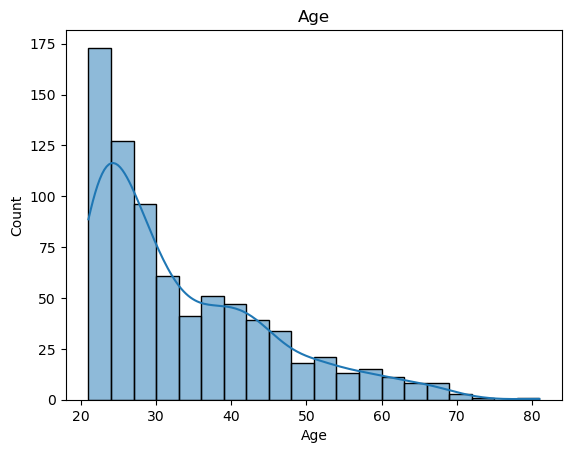

In [459]:
sns.histplot(df1['Age'], bins = 20, kde = True)
plt.title('Age')

In [460]:
df1['Age'] = df1['Age'].replace(0, np.nan)

In [461]:
# 히스토그램을 보았을 때, 20대의 사람들이 밀집돼 있기 때문에, 밀집된 인원들이 미당뇨균 환자라면 중앙값이 더 이로울 것 같아서, 결측치 대체는 중앙값으로 설정.
df1['Age'].transform(lambda x: x.fillna(x.median()))

0      50
1      31
2      32
3      21
4      33
       ..
763    63
764    27
765    30
766    47
767    23
Name: Age, Length: 768, dtype: int64

/var/folders/3t/75nxhs_x6gz3sd68vbz2t1qh0000gn/T/ipykernel_5882/1594813469.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Outcome', y = 'Age', data = df1,


Text(0, 0.5, 'Age')

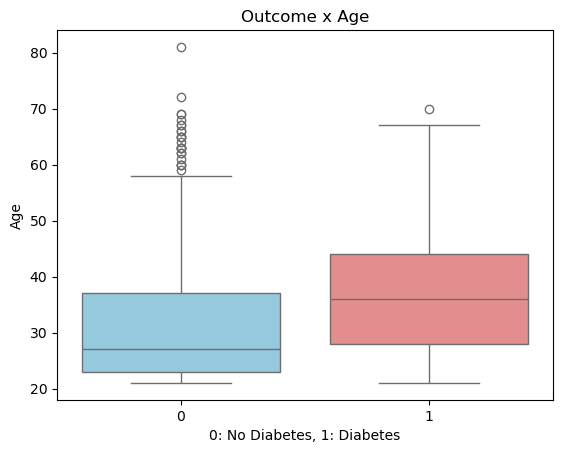

In [462]:
sns.boxplot(x = 'Outcome', y = 'Age', data = df1,
            palette = ['skyblue', 'lightcoral'])
plt.title('Outcome x Age')
plt.xlabel('0: No Diabetes, 1: Diabetes')
plt.ylabel('Age')

• 당뇨가 있을 수록 Age가 높을 수 있음. 중앙값이 아닐 때보다 높게 나타남.

In [463]:
# BMI 범주를 나누어서 BMI_group을 만들겠음.
# 본인도 BMI가 어느 정도 나가는 편이어서 궁금해서 해봤습니다..
q1 = df1['BMI'].quantile(0.25)
q3 = df1['BMI'].quantile(0.75)

df1['BMI_group'] = pd.cut(df1['BMI'],
                    bins = [-float('inf'), q1, q3, float('inf')],
                    labels = ['Low', 'Middle', 'High'],
                    right = False)


In [464]:
df1.groupby('BMI_group')['Outcome'].mean()

/var/folders/3t/75nxhs_x6gz3sd68vbz2t1qh0000gn/T/ipykernel_5882/1180401231.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby('BMI_group')['Outcome'].mean()


BMI_group
Low       0.105263
Middle    0.400000
High      0.487047
Name: Outcome, dtype: float64

# **모델링하기**

In [465]:
# 2) 목표변수 / 설명변수 설정
# 파생 변수는 추가하고, 필요 없는 변수는 빼기

X = df1[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction', 'Age', 'BMI_group']]
Y = df1['Outcome'] # Y값에는 결측치가 존재해서는 안됨

In [508]:
# 라벨 인코딩
mapping = {
    "Low": 0,
    "Middle": 1,
    "High": 2
}

X['BMI_group'] = X["BMI_group"].map(mapping)

/var/folders/3t/75nxhs_x6gz3sd68vbz2t1qh0000gn/T/ipykernel_5882/1390734052.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['BMI_group'] = X["BMI_group"].map(mapping)


In [509]:
# 3) 학습데이터와 검증데이터를 분할
# pip install scikit-learn
from sklearn.model_selection import train_test_split

In [510]:
train_test_split(X,Y) # X 데이터의 학습, 검증 데이터 & Y 데이터의 학습, 검증데이터 4개로 분리됨

[     Pregnancies     Glucose  BloodPressure  SkinThickness  Insulin  \
 124            0  113.000000           76.0           29.0    130.0   
 55             1   73.000000           50.0           10.0     66.0   
 11            10  168.000000           74.0           29.0    180.0   
 652            5  123.000000           74.0           40.0     77.0   
 502            6  121.686763           68.0           41.0    130.0   
 ..           ...         ...            ...            ...      ...   
 103            1   81.000000           72.0           18.0     40.0   
 309            2  124.000000           68.0           28.0    205.0   
 206            8  196.000000           76.0           29.0    280.0   
 345            8  126.000000           88.0           36.0    108.0   
 5              5  116.000000           74.0           29.0    130.0   
 
      DiabetesPedigreeFunction  Age BMI_group  
 124                     0.278   23         1  
 55                      0.248   21   

In [531]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=1234)
# train_test_split()에 별도의 옵션을 지정하지 않으면 75:25로 학습:검증 분할됨
# random_state을 지정해야 같은 결과가 나옴

In [532]:
X.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
DiabetesPedigreeFunction    0
Age                         0
BMI_group                   0
dtype: int64

=> X에도 결측치가 없는 데이터이지만, 추후 새로 들어올 데이터에 결측치가 존재할 수 있음

# **각자 공부한 모델 쓰기**

In [533]:
# 4) 학습 수행
from sklearn.ensemble import GradientBoostingClassifier

In [534]:
model = GradientBoostingClassifier()
model.fit(X_train, Y_train) # 학습 수행

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [535]:
# 5) 성능 확인
from sklearn.metrics import accuracy_score
# 정확도 : 전체 데이터 중 얼만큼 정확히 분류했는지 비율

In [536]:
Y_train_pred = model.predict(X_train)

In [537]:
Y_test_pred = model.predict(X_test)

In [538]:
print('학습 정확도 : ', accuracy_score(Y_train, Y_train_pred)) # 여러 알고리즘에 대한 모델을 비교할 때 확인해야 함
print('검증 정확도 : ', accuracy_score(Y_test, Y_test_pred))

학습 정확도 :  0.9236111111111112
검증 정확도 :  0.7239583333333334


### 과적합(Overfitting)

- 과적합 : 학습 데이터에 대해서는 Model이 높은 성능을 나타내지만, 검증데이터에서는 성능이 낮게 나오는 현상
- 해결 : 특성공학을 통해 데이터를 더 깔끔하게 생성"

### **Gradient Boosting** 
• Gradient Boosting은 Boosting기법의 앙상블(Ensemble)로, 이전 모델의 오차를 다음 모델의 학습시키는 기법이다. <br><br>
-> Ensemble(앙상블): 여러 모델을 합쳐 하나의 강력한 모델을 만드는 방법 <br>
-> Gradient 의미: 오차를 줄이는 방향, 손실함수를 기울기 방향으로 줄여가며 학습하는 머신러닝 모델 <br><br>
• 약한 학습기인 결정트리(Decision Tree)를 사용하여, 이를 계속 보완해가는 방식이다. <br><br>
• 언제 사용하는가? (분류 / 회귀 모두 사용 가능) <br><br>
1. 분류: 스팸 메일 분류, 고객 이탈 에측, 신용등급 분류, 질병 진단 <br>
2. 회귀: 집값 예측, 매출 예측, 수요 예측<br><br>
• 장점) <br>
-> 비선형 데이터 처리 가능 / 매우 높은 예측 가능성 / 복잡한 패턴도 매우 유용 / 표 형태 데이터에서 매우 강함. <br><br>
• 단점) <br>
-> 학습 시간이 오래 걸림 / 하이퍼파라미터가 많아 튜닝이 필요함 / 너무 많아서 학습시 과적합이 발생할 수 있음.

In [539]:
# 4) 학습 수행
from sklearn.pipeline import make_pipeline # 특성공학 + 학습
from sklearn.impute import SimpleImputer # 결측값 단순 대치 기법
from sklearn.tree import DecisionTreeClassifier # 학습 알고리즘(의사결정나무)
from sklearn.preprocessing import StandardScaler #Standard Scaling

In [540]:
# 파이프라인 구조 설계
#스케일링 하고 싶으면 StandardScaler() 사용

model_pipe = make_pipeline(  
    SimpleImputer(strategy='median'),
    GradientBoostingClassifier(random_state=1234)
)
model_pipe

,steps,"[('simpleimputer', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,loss,'log_loss'


In [541]:
from sklearn.model_selection import GridSearchCV

#### **공부한 모델의 하이퍼파라미터**

- 여기에 정리하기
- ex: 하이퍼 파라미터의 종류는 ~~가 있고, 값을 키우면 과적합이 발생할 수 있다.

• n_estimators: 트리 개수 <br><br>
• learning_rate: 한 번 학습할 때, 얼마나 학습하는지에 대한 정도 <br><br>
• max_depth: 각 트리의 복잡도 제한 <br><br>
• subsample: 일부 데이터만 사용하여 학습, 과적합 완화에 도움됨. <br><br>
• min_samples_split: 분할하기 위한 최소 샘플 수, 기준이 작을 수록 세세하게 분할하기 때문에 과적합 확률 증가<br><br>
• min_samples_leaf: 리프 노드에 최소 몇 개의 샘플을 남길지 <br><br>
-> min_samples_leaf = 6이라면 15/5 분할 불가능 <br><br>

* n_estimators, learning_rate, max_depth -> 값이 높을 수록 모델이 복잡해짐.<br><br>
* subsample -> 1보다 적으면 사용하는 데이터가 적어져, 과적합 확률 낮아짐.<br><br>
* min_samples_split, min_samples_leaf -> 높을 수록 과적합 확률 낮아짐. 적을 수록 세세하게 쪼개기 때문.

In [564]:
# 하이퍼파라미터 튜닝 및 교차검증
hyperparam = {
    'gradientboostingclassifier__n_estimators': [100, 200],
    'gradientboostingclassifier__learning_rate': [0.001, 0.1],
    'gradientboostingclassifier__max_depth': [3, 4],
    'gradientboostingclassifier__min_samples_split': [9, 10],
    'gradientboostingclassifier__subsample': [0.75, 0.8]}

grid_model1 = GridSearchCV(model_pipe, param_grid = hyperparam, cv=3,
                          scoring='f1', n_jobs=-1)
grid_model1.fit(X_train, Y_train)
best_model1 = grid_model1.best_estimator_

In [565]:
best_model1

,steps,"[('simpleimputer', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,loss,'log_loss'


In [566]:
# 5) 평가
Y_train_pred = best_model1.predict(X_train) # 학습 데이터의 예측값 계산
Y_test_pred = best_model1.predict(X_test) # 검증데이터의 예측값 계산

In [567]:
from sklearn.metrics import classification_report

In [568]:
# 학습 성능 평가
print(classification_report(Y_train, Y_train_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       379
           1       0.92      0.86      0.89       197

    accuracy                           0.93       576
   macro avg       0.92      0.91      0.92       576
weighted avg       0.93      0.93      0.93       576



In [569]:
# 일반화 성능 평가
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.78      0.87      0.82       121
           1       0.72      0.58      0.64        71

    accuracy                           0.76       192
   macro avg       0.75      0.72      0.73       192
weighted avg       0.76      0.76      0.75       192



# **성능을 높이기 위한 방안**

1. test 데이터의 정확도가 test 데이터의 정확도보다 많이 낮으면 과적합
2. 하이퍼파라미터 튜닝, 추가적인 전처리(변수 제거) 혹은 파생변수 생성 으로 이를 해결 할 수 있다.  